# Amazon Customer Behavioral Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_raw = pd.read_csv("../datasets/Amazon_Customer_Behavior_Survey.csv")
print(df_raw.shape)
df_raw.head(3)

(602, 23)


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency.1,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
0,2023/06/04 1:28:19 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care,Yes,Few times a week,Keyword,Multiple pages,1,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,2023/06/04 2:30:44 PM GMT+5:30,23,Female,Once a month,Clothing and Fashion,Yes,Few times a month,Keyword,Multiple pages,1,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,2023/06/04 5:04:56 PM GMT+5:30,24,Prefer not to say,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,Keyword,Multiple pages,2,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy


In [3]:
df = df_raw.copy()
df.dropna(subset=["Product_Search_Method"], inplace=True)
df.reset_index(drop=True, inplace=True)

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df.columns = [c.strip() for c in df.columns]

bins = np.array([0, 18, 25, 35, 45, 100])
labels = ["<18", "18-25", "26-35", "36-45", "45+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

freq_order = {"Less than once a month": 1, "Once a month": 2, "Few times a month": 3, "Once a week": 4, "Multiple times a week": 5}
df["purchase_freq_num"] = df["Purchase_Frequency"].map(freq_order)

browse_order = {"Rarely": 1, "Few times a month": 2, "Few times a week": 3, "Multiple times a day": 4}
df["browse_freq_num"] = df["Browsing_Frequency"].map(browse_order)

df["primary_category"] = df["Purchase_Categories"].apply(lambda x: x.split(";")[0].strip())

df.to_csv("../datasets/Amazon_Customer_Behavior_Survey_CLEANED.csv", index=False)
df.dtypes

Timestamp                                  datetime64[us, UTC-05:30]
age                                                            int64
Gender                                                           str
Purchase_Frequency                                               str
Purchase_Categories                                              str
Personalized_Recommendation_Frequency                            str
Browsing_Frequency                                               str
Product_Search_Method                                            str
Search_Result_Exploration                                        str
Customer_Reviews_Importance                                    int64
Add_to_Cart_Browsing                                             str
Cart_Completion_Frequency                                        str
Cart_Abandonment_Factors                                         str
Saveforlater_Frequency                                           str
Review_Left                       

In [4]:
age_arr = df["age"].to_numpy()
sat_arr = df["Shopping_Satisfaction"].to_numpy()

print(f"Age   — Mean: {np.mean(age_arr):.1f}, Median: {np.median(age_arr):.1f}, Std: {np.std(age_arr):.1f}, Min/Max: {np.min(age_arr)}/{np.max(age_arr)}")
print(f"Sat   — Mean: {np.mean(sat_arr):.2f}, Std: {np.std(sat_arr):.2f}")
p25, p75 = np.percentile(age_arr, [25, 75])
print(f"Age percentiles — 25th: {p25}, 75th: {p75}")

df[["age","Shopping_Satisfaction","Customer_Reviews_Importance","Rating_Accuracy","purchase_freq_num","browse_freq_num"]].describe().round(2)

Age   — Mean: 30.8, Median: 26.0, Std: 10.2, Min/Max: 3/67
Sat   — Mean: 2.46, Std: 1.01
Age percentiles — 25th: 23.0, 75th: 36.0


,age,Shopping_Satisfaction,Customer_Reviews_Importance,Rating_Accuracy,purchase_freq_num,browse_freq_num
count,600.00,600.00,600.00,600.00,600.00,600.00
mean,30.78,2.46,2.48,2.67,2.78,2.54
std,10.18,1.01,1.19,0.90,1.23,0.87
min,3.00,1.00,1.00,1.00,1.00,1.00
25%,23.00,2.00,1.00,2.00,2.00,2.00
50%,26.00,2.00,3.00,3.00,3.00,3.00
75%,36.00,3.00,3.00,3.00,4.00,3.00
max,67.00,5.00,5.00,5.00,5.00,4.00


In [5]:
print(df["Purchase_Frequency"].value_counts())
print()
print(df["primary_category"].value_counts())
print()
print(df["Gender"].value_counts())
print()
print(pd.crosstab(df["Gender"], df["primary_category"]))
print()
print(df.groupby("age_group", observed=True)["Shopping_Satisfaction"].mean().round(2))
print()
print(df.groupby("Gender")["purchase_freq_num"].mean().round(2))

Purchase_Frequency
Few times a month         202
Less than once a month    124
Once a week               112
Once a month              106
Multiple times a week      56
Name: count, dtype: int64

primary_category
Beauty and Personal Care      246
Clothing and Fashion          162
Groceries and Gourmet Food    111
others                         48
Home and Kitchen               33
Name: count, dtype: int64

Gender
Female               350
Male                 142
Prefer not to say     89
Others                19
Name: count, dtype: int64

primary_category   Beauty and Personal Care  Clothing and Fashion  \
Gender                                                              
Female                                  167                    87   
Male                                     35                    42   
Others                                    6                     3   
Prefer not to say                        38                    30   

primary_category   Groceries and Gourmet 

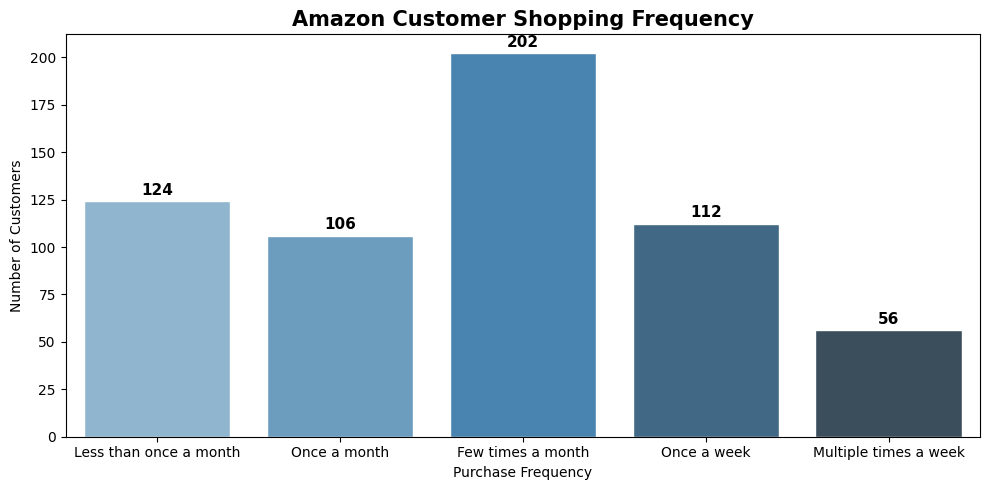

In [6]:
freq_order_list = ["Less than once a month","Once a month","Few times a month","Once a week","Multiple times a week"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="Purchase_Frequency", order=freq_order_list, palette="Blues_d", edgecolor="white", ax=ax)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2.0, p.get_height() + 2), ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Amazon Customer Shopping Frequency", fontsize=15, fontweight="bold")
ax.set_xlabel("Purchase Frequency")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../outputs/charts/01_shopping_frequency_countplot.png", dpi=150, bbox_inches="tight")
plt.show()

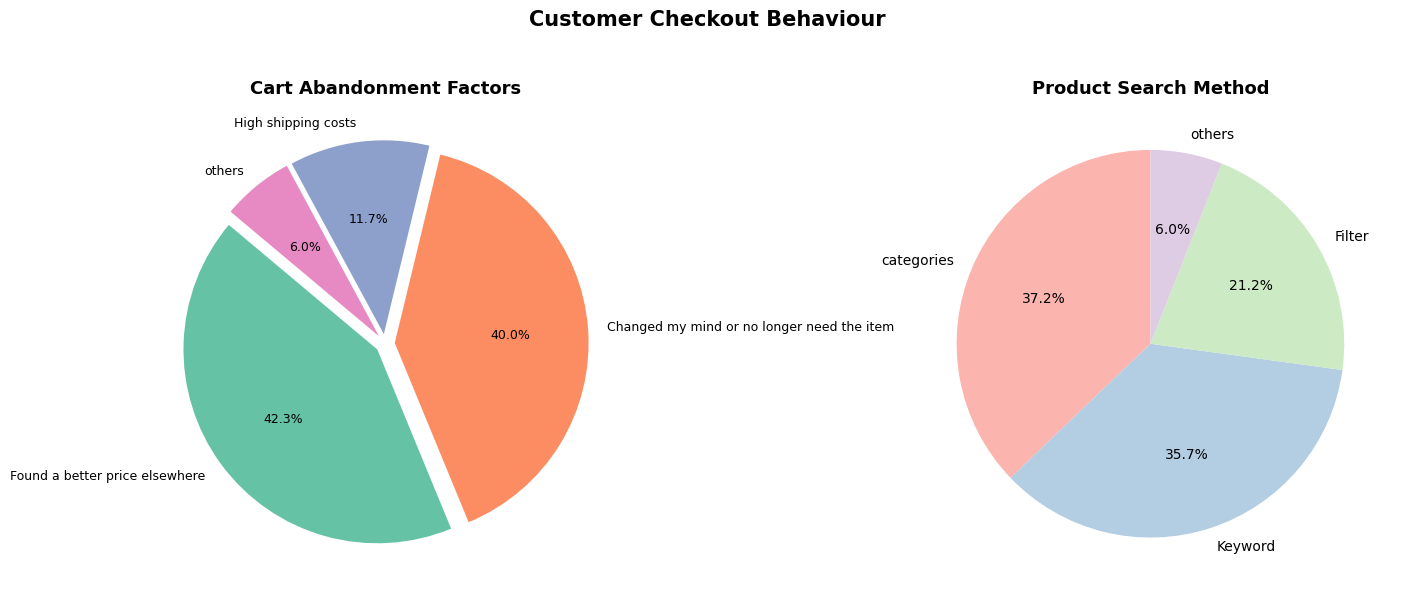

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

abandon_counts = df["Cart_Abandonment_Factors"].value_counts()
axes[0].pie(abandon_counts, labels=abandon_counts.index, autopct="%1.1f%%", startangle=140,
            explode=[0.05]*len(abandon_counts), colors=sns.color_palette("Set2", len(abandon_counts)), textprops={"fontsize": 9})
axes[0].set_title("Cart Abandonment Factors", fontsize=13, fontweight="bold")

search_counts = df["Product_Search_Method"].value_counts()
axes[1].pie(search_counts, labels=search_counts.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("Pastel1", len(search_counts)), textprops={"fontsize": 10})
axes[1].set_title("Product Search Method", fontsize=13, fontweight="bold")

plt.suptitle("Customer Checkout Behaviour", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/charts/02_pie_checkout_behaviour.png", dpi=150, bbox_inches="tight")
plt.show()

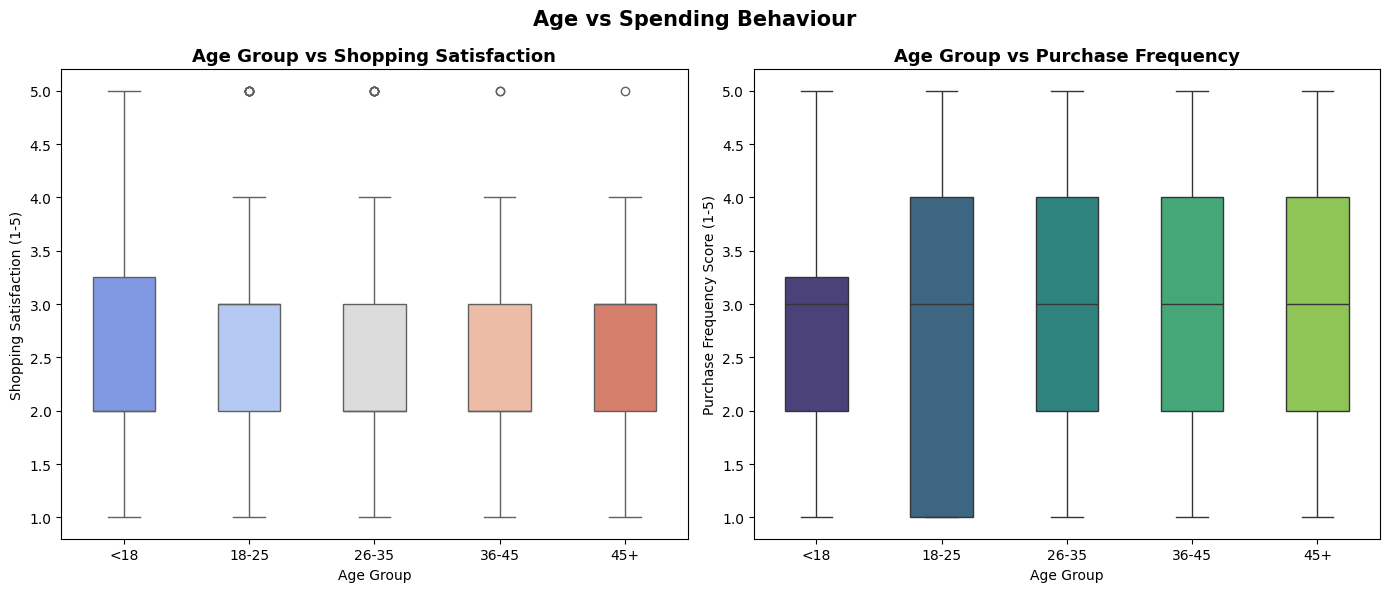

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
age_order = ["<18","18-25","26-35","36-45","45+"]

sns.boxplot(data=df, x="age_group", y="Shopping_Satisfaction", palette="coolwarm", order=age_order, width=0.5, ax=axes[0])
axes[0].set_title("Age Group vs Shopping Satisfaction", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Shopping Satisfaction (1-5)")

sns.boxplot(data=df, x="age_group", y="purchase_freq_num", palette="viridis", order=age_order, width=0.5, ax=axes[1])
axes[1].set_title("Age Group vs Purchase Frequency", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Purchase Frequency Score (1-5)")

plt.suptitle("Age vs Spending Behaviour", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/charts/03_age_vs_spending_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

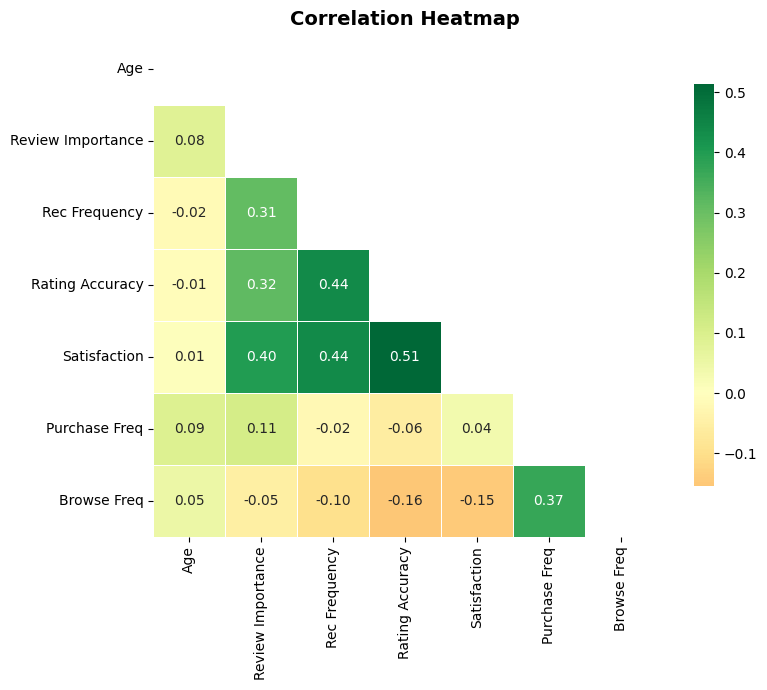

In [9]:
numeric_cols = ["age","Customer_Reviews_Importance","Personalized_Recommendation_Frequency.1","Rating_Accuracy","Shopping_Satisfaction","purchase_freq_num","browse_freq_num"]
corr = df[numeric_cols].corr()
corr.rename(columns={"age":"Age","Customer_Reviews_Importance":"Review Importance","Personalized_Recommendation_Frequency.1":"Rec Frequency","Rating_Accuracy":"Rating Accuracy","Shopping_Satisfaction":"Satisfaction","purchase_freq_num":"Purchase Freq","browse_freq_num":"Browse Freq"},
            index={"age":"Age","Customer_Reviews_Importance":"Review Importance","Personalized_Recommendation_Frequency.1":"Rec Frequency","Rating_Accuracy":"Rating Accuracy","Shopping_Satisfaction":"Satisfaction","purchase_freq_num":"Purchase Freq","browse_freq_num":"Browse Freq"}, inplace=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, linecolor="white", square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/charts/04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

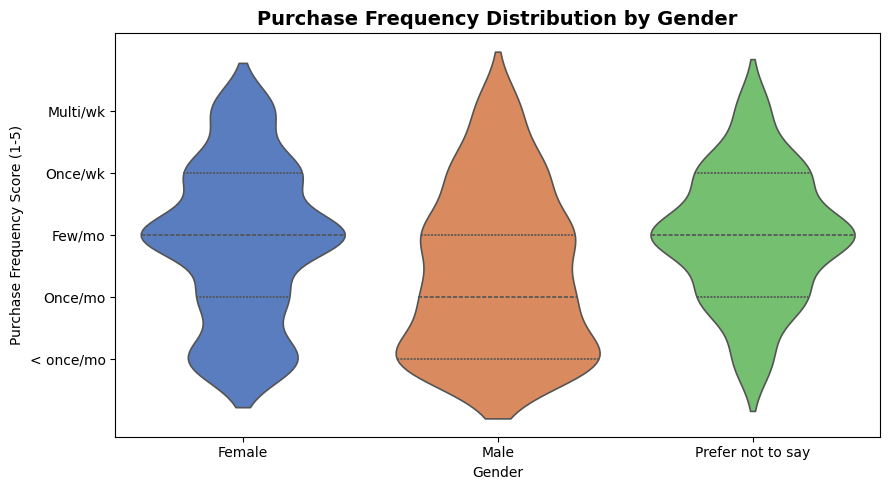

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
gender_order = [g for g in ["Female","Male","Prefer not to say"] if g in df["Gender"].unique()]
sns.violinplot(data=df[df["Gender"].isin(gender_order)], x="Gender", y="purchase_freq_num",
               order=gender_order, palette="muted", inner="quartile", linewidth=1.2, ax=ax)
ax.set_title("Purchase Frequency Distribution by Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Purchase Frequency Score (1-5)")
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(["< once/mo","Once/mo","Few/mo","Once/wk","Multi/wk"])
plt.tight_layout()
plt.savefig("../outputs/charts/05_gender_vs_purchase_freq_violin.png", dpi=150, bbox_inches="tight")
plt.show()

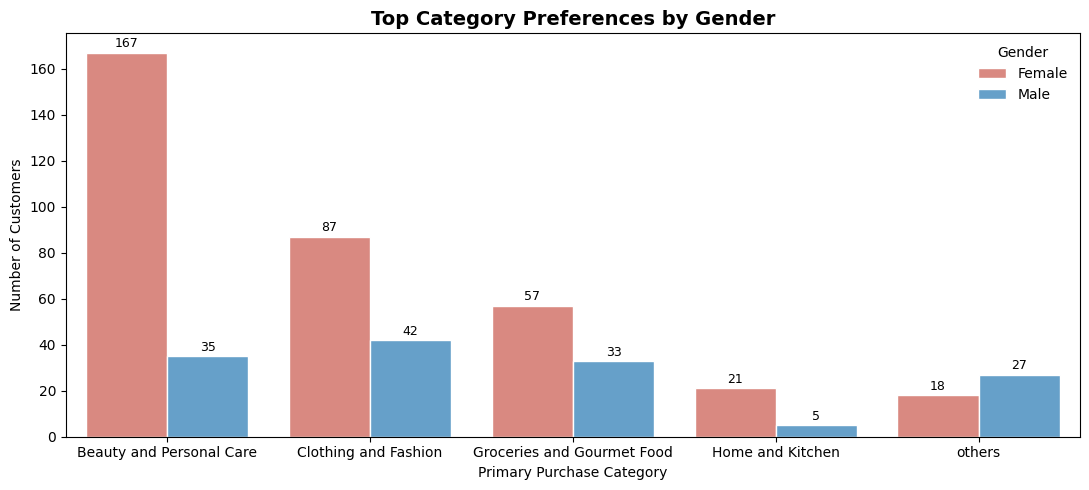

In [11]:
top_cats = df["primary_category"].value_counts().head(5).index.tolist()
ct2 = (df[df["Gender"].isin(["Female","Male"])].groupby(["primary_category","Gender"]).size()
       .reset_index(name="count").query("primary_category in @top_cats"))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=ct2, x="primary_category", y="count", hue="Gender",
            palette={"Female":"#E87D72","Male":"#56A3D9"}, edgecolor="white", ax=ax)
ax.set_title("Top Category Preferences by Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Primary Purchase Category")
ax.set_ylabel("Number of Customers")
ax.legend(title="Gender", frameon=False)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{int(h)}", (p.get_x() + p.get_width()/2, h+1), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/charts/06_gender_category_preference.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
conditions = [
    (df["purchase_freq_num"] >= 4) & (df["browse_freq_num"] >= 3),
    (df["purchase_freq_num"] >= 3) & (df["browse_freq_num"] >= 2),
    (df["purchase_freq_num"] <= 2),
]
df["segment"] = np.select(conditions, ["Power Buyer","Regular Buyer","Occasional Buyer"], default="Casual Browser")

print(df["segment"].value_counts())
print()
df.groupby("segment").agg(avg_age=("age","mean"), avg_satisfaction=("Shopping_Satisfaction","mean"),
                           avg_review_importance=("Customer_Reviews_Importance","mean"), count=("age","count")).round(2)

segment
Regular Buyer       237
Occasional Buyer    230
Power Buyer         116
Casual Browser       17
Name: count, dtype: int64



,avg_age,avg_satisfaction,avg_review_importance,count
segment,,,,
Casual Browser,31.71,2.76,2.88,17
Occasional Buyer,29.17,2.41,2.30,230
Power Buyer,31.07,2.47,2.56,116
Regular Buyer,32.14,2.49,2.59,237
